In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import os 
from typing import Tuple

emr_co2 = pd.read_csv(r'co2_calc\emissions\total_all.csv')
global_co2 = pd.read_csv(r'co2_calc\global_emissions\total_all.csv')

dash_emr = pd.read_csv(r'diet_calc\scores\dash_dixon\total_all.csv')
dash_global = pd.read_csv(r'diet_calc\scores\dash_dixon\global\total_all.csv')

em_dash_male = pd.read_csv(r'diet_calc\scores\dash_dixon\total_males.csv')
gl_dash_male = pd.read_csv(r'diet_calc\scores\dash_dixon\global\total_males.csv')

em_dash_female = pd.read_csv(r'diet_calc\scores\dash_dixon\total_females.csv')
gl_dash_female = pd.read_csv(r'diet_calc\scores\dash_dixon\global\total_females.csv')


In [2]:

def eat_fix (df):
    df = df.transpose().reset_index()
    df.columns = ['year', 'score']
    df.drop(0, inplace=True)
    df['year'] = df['year'].astype(int)
    df['score'] = df['score'].astype(float)
    return df

eat_emr = pd.read_csv(r'diet_calc\scores\eat\total_all.csv')
eat_global = pd.read_csv(r'diet_calc\scores\eat_global\total_all.csv')
eat_global = eat_fix(eat_global)

em_eat_male = pd.read_csv(r'diet_calc\scores\eat\total_males.csv')
gl_eat_male = pd.read_csv(r'diet_calc\scores\eat_global\total_males.csv')
gl_eat_male = eat_fix(gl_eat_male)

em_eat_female = pd.read_csv(r'diet_calc\scores\eat\total_females.csv')
gl_eat_female = pd.read_csv(r'diet_calc\scores\eat_global\total_females.csv')
gl_eat_female = eat_fix(gl_eat_female)

In [3]:
emr_medit = pd.read_csv(r'diet_calc\scores\medit_new\total_all.csv')
glo_medit = pd.read_csv(r'diet_calc\scores\medit_new\global\total_all.csv')

emr_medit_males = pd.read_csv(r'diet_calc\scores\medit_new\total_males.csv')
glo_medit_males = pd.read_csv(r'diet_calc\scores\medit_new\global\total_males.csv')

emr_medit_females = pd.read_csv(r'diet_calc\scores\medit_new\total_females.csv')
glo_medit_females = pd.read_csv(r'diet_calc\scores\medit_new\global\total_females.csv')

In [4]:
emr_phdi = pd.read_csv(r'diet_calc\scores\phdi\total_all.csv')
glo_phdi = pd.read_csv(r'diet_calc\scores\phdi_global\total_all.csv')
glo_phdi = eat_fix(glo_phdi)

em_phdi_male = pd.read_csv(r'diet_calc\scores\phdi\total_males.csv')
gl_phdi_male = pd.read_csv(r'diet_calc\scores\phdi_global\total_males.csv')
gl_phdi_male = eat_fix(gl_phdi_male)

em_phdi_female = pd.read_csv(r'diet_calc\scores\phdi\total_females.csv')
gl_phdi_female = pd.read_csv(r'diet_calc\scores\phdi_global\total_females.csv')
gl_phdi_female = eat_fix(gl_phdi_female)

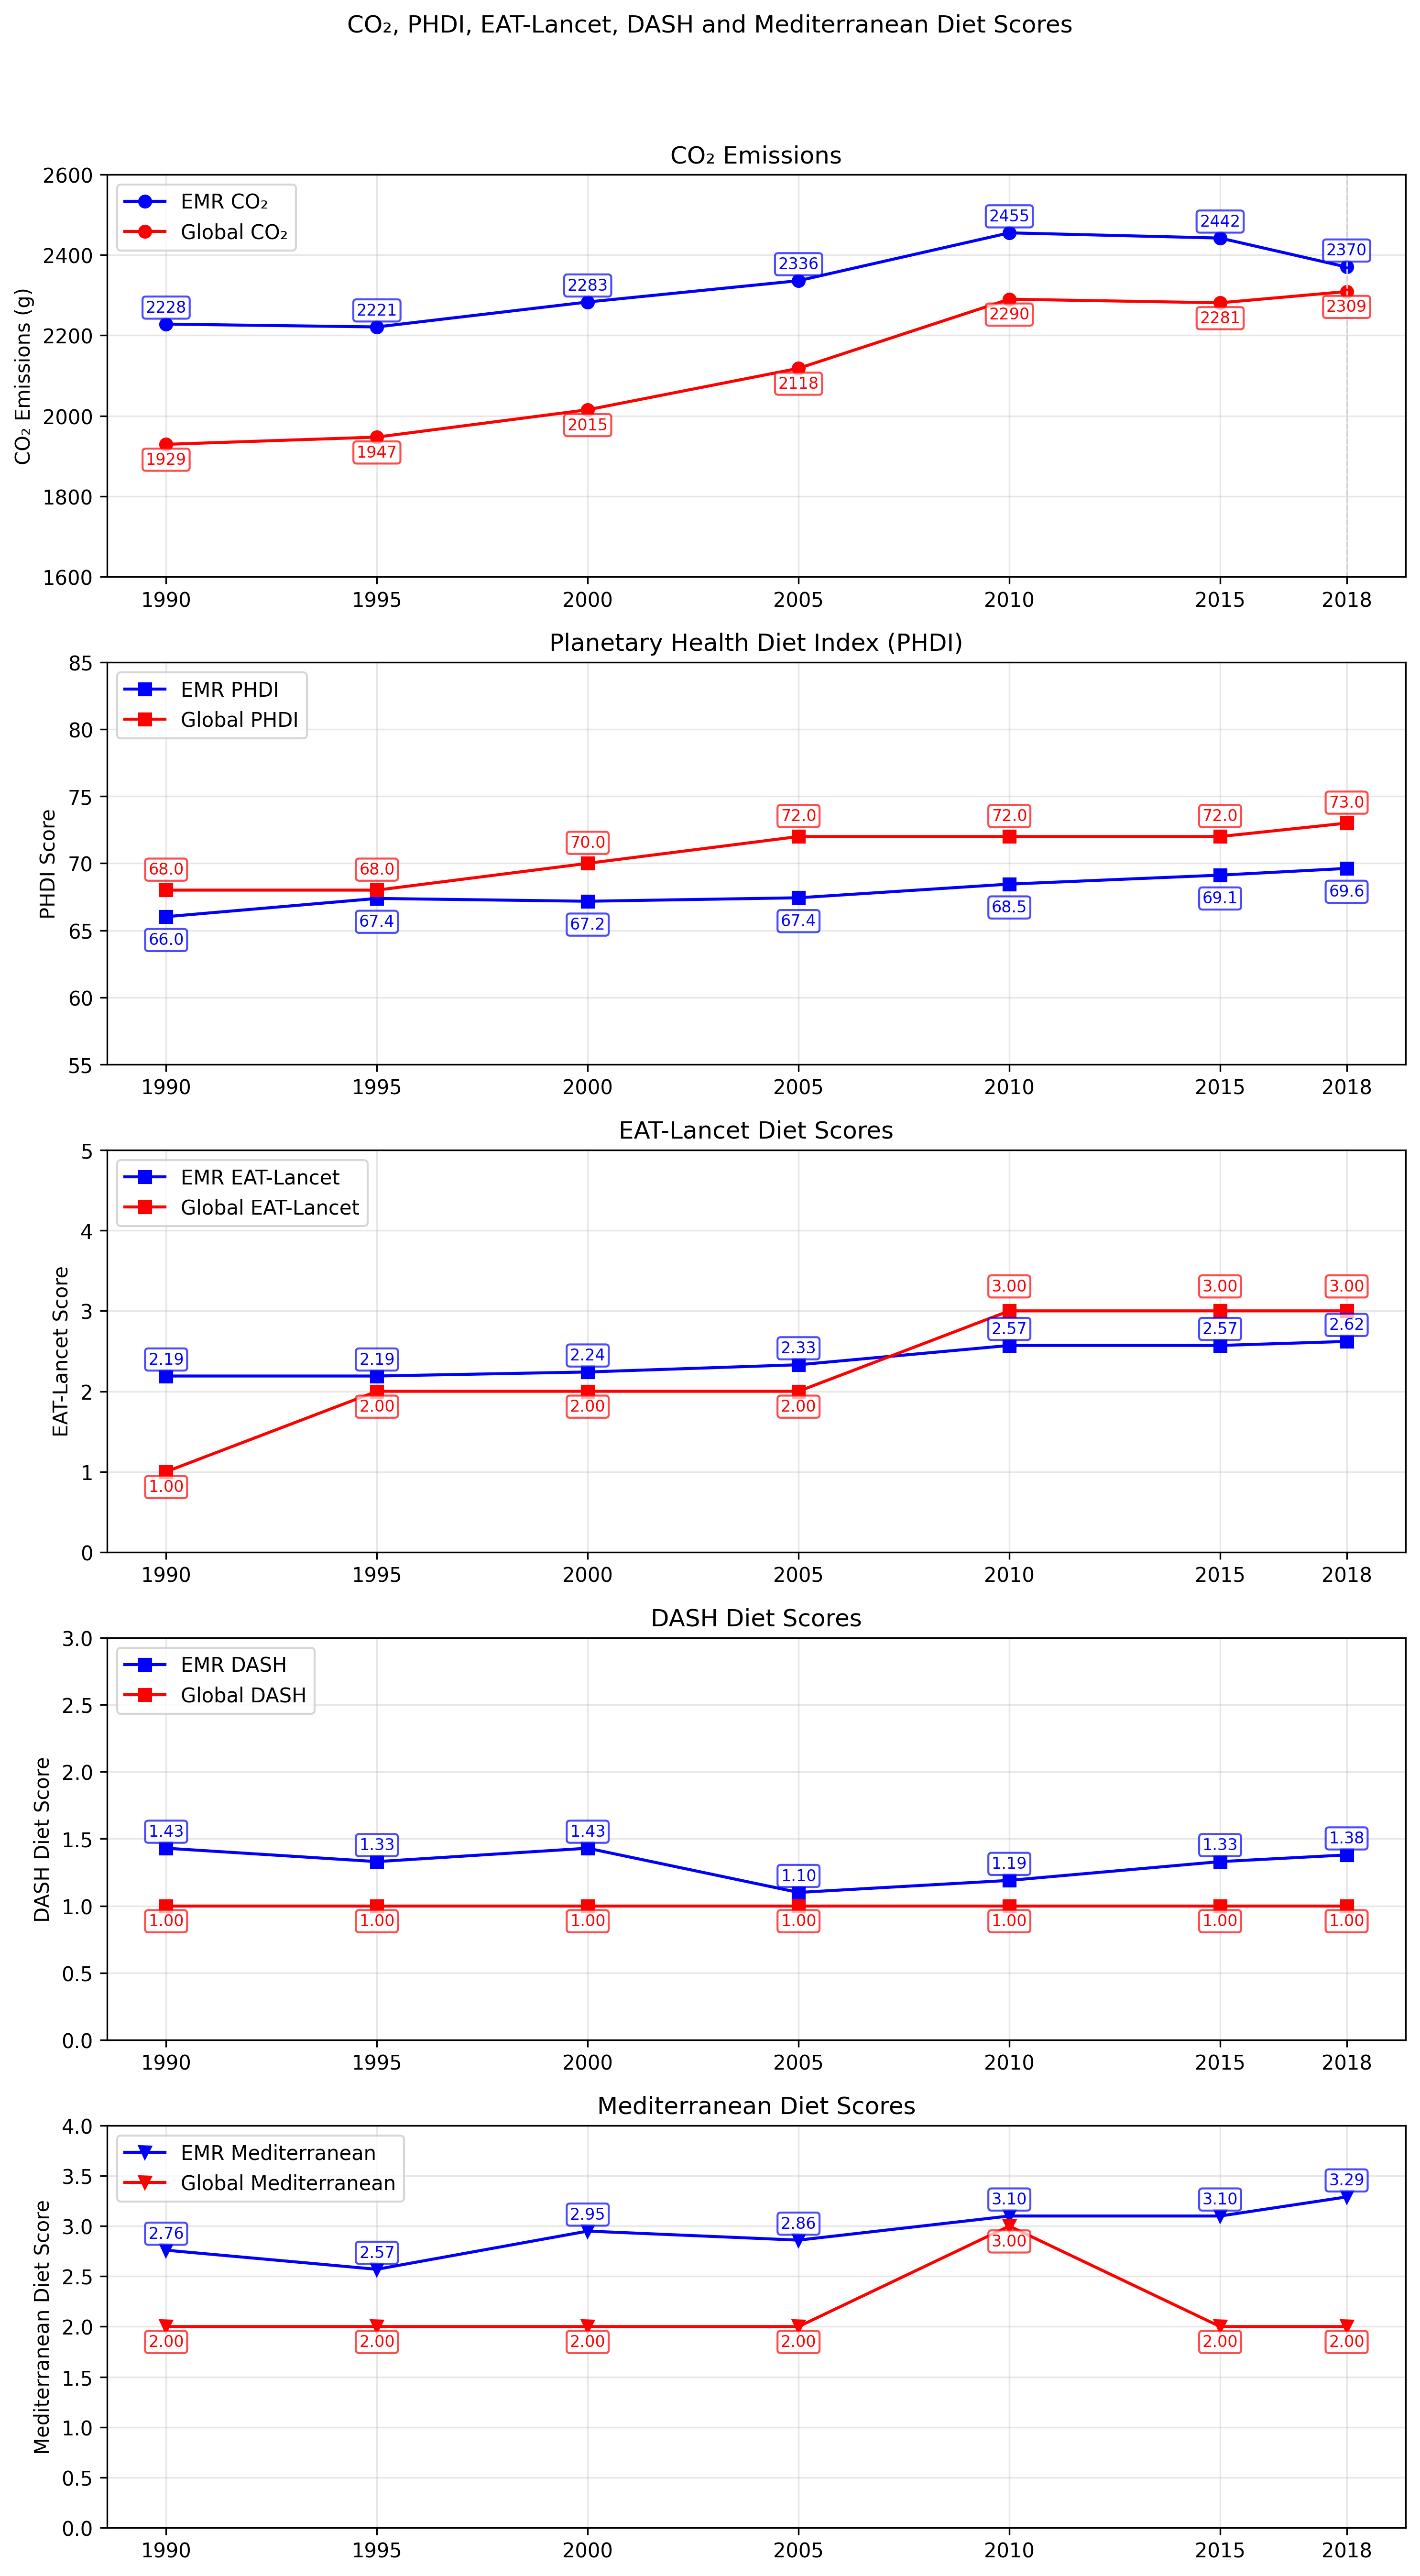

In [7]:

# --- Helpers ---
def _prepare_emr_scores(emr_df: pd.DataFrame, n_years: int = 7) -> pd.DataFrame:
    years = emr_df.columns[1:1 + n_years].astype(int)
    scores = emr_df.iloc[:, 1:1 + n_years].mean(axis=0, numeric_only=True).round(2).values
    return pd.DataFrame({"year": years, "score": scores})


def _prepare_global_scores(global_df: pd.DataFrame, n_rows: int = 7) -> pd.DataFrame:
    out = global_df.iloc[:n_rows].copy()
    out = out.astype({"year": int, "score": float})
    return out.reset_index(drop=True)


def _prepare_co2(emr_co2: pd.DataFrame, global_co2: pd.DataFrame, n_rows: int = 7) -> Tuple[pd.DataFrame, pd.DataFrame]:
    emr_co2_agg = (
        emr_co2.groupby("year")["emissions"]
        .mean()
        .round(0)
        .astype(int)
        .reset_index()
    )[:n_rows]
    global_co2_trim = global_co2.iloc[:n_rows].round(0).astype({"emissions": int}).reset_index(drop=True)
    return emr_co2_agg, global_co2_trim


# --- Main plotting function ---
def plot_five_panel(
    emr_co2: pd.DataFrame,
    global_co2: pd.DataFrame,
    emr_dash: pd.DataFrame,
    global_dash: pd.DataFrame,
    emr_eat: pd.DataFrame,
    global_eat: pd.DataFrame,
    emr_medit: pd.DataFrame,
    global_medit: pd.DataFrame,
    emr_phdi: pd.DataFrame,
    global_phdi: pd.DataFrame,
    gender: str = "all",
    n_years: int = 7,
    figsize=(10, 18),
    dpi: int = 300,
):
    """
    5 stacked panels:
      1) CO2 emissions (EMR vs Global)
      2) EAT-Lancet scores (EMR vs Global)    <- moved to 2nd panel
      3) DASH Diet scores (EMR vs Global)
      4) Mediterranean Diet scores (EMR vs Global)
      5) Planetary Health Diet Index (PHDI) scores (EMR vs Global)

    EMR-style dataframes are expected to have year columns in columns[1:].
    Global dataframes must have columns ['year', 'score'].
    """
    # Standard colors
    C_EMR = "blue"
    C_GLOBAL = "red"

    # Prepare data
    emr_co2_agg, global_co2_trim = _prepare_co2(emr_co2, global_co2, n_rows=n_years)

    emr_dash_ready = _prepare_emr_scores(emr_dash, n_years)
    global_dash_ready = _prepare_global_scores(global_dash, n_rows=n_years)

    emr_eat_ready = _prepare_emr_scores(emr_eat, n_years)
    global_eat_ready = _prepare_global_scores(global_eat, n_rows=n_years)

    emr_medit_ready = _prepare_emr_scores(emr_medit, n_years)
    global_medit_ready = _prepare_global_scores(global_medit, n_rows=n_years)

    emr_phdi_ready = _prepare_emr_scores(emr_phdi, n_years)
    global_phdi_ready = _prepare_global_scores(global_phdi, n_rows=n_years)

    # Create figure and axes
    fig, axes = plt.subplots(5, 1, figsize=figsize, dpi=dpi, sharex=True)
    # reorder axes so EAT is second
    ax_co2,ax_phdi, ax_eat, ax_dash, ax_medit  = axes

    # ---------- Panel 1: CO2 ----------
    years_co2 = sorted(set(list(emr_co2_agg["year"]) + list(global_co2_trim["year"])))
    ax_co2.plot(emr_co2_agg["year"], emr_co2_agg["emissions"], marker="o", color=C_EMR, label="EMR CO₂")
    ax_co2.plot(global_co2_trim["year"], global_co2_trim["emissions"], marker="o", color=C_GLOBAL, label="Global CO₂")
    ax_co2.set_ylabel("CO₂ Emissions (g)")
    ax_co2.set_title("CO₂ Emissions")
    ax_co2.grid(alpha=0.3)
    ax_co2.axvline(x=2018, color="lightgray", linestyle="--", linewidth=0.7)
    ax_co2.set_ylim(1600, 2600)
    ax_co2.set_xticks(years_co2)
    ax_co2.set_xticklabels(years_co2)
    ax_co2.tick_params(axis="x", rotation=0, labelbottom=True)
    # annotations
    for _, r in emr_co2_agg.iterrows():
        ax_co2.annotate(f"{int(r['emissions'])}", (r["year"], r["emissions"]),
                        textcoords="offset points", xytext=(0, 6), ha="center",
                        fontsize=8, color=C_EMR,
                        bbox=dict(boxstyle="round,pad=0.2", edgecolor=C_EMR, facecolor="white", alpha=0.7))
    for _, r in global_co2_trim.iterrows():
        ax_co2.annotate(f"{int(r['emissions'])}", (r["year"], r["emissions"]),
                        textcoords="offset points", xytext=(0, -10), ha="center",
                        fontsize=8, color=C_GLOBAL,
                        bbox=dict(boxstyle="round,pad=0.2", edgecolor=C_GLOBAL, facecolor="white", alpha=0.7))
    ax_co2.legend(loc="upper left")

    # ---------- Panel 2: EAT-Lancet (moved up) ----------
    years_eat = sorted(set(list(emr_eat_ready["year"]) + list(global_eat_ready["year"])))
    ax_eat.plot(emr_eat_ready["year"], emr_eat_ready["score"], marker="s", color=C_EMR, label="EMR EAT-Lancet")
    ax_eat.plot(global_eat_ready["year"], global_eat_ready["score"], marker="s", color=C_GLOBAL, label="Global EAT-Lancet")
    ax_eat.set_ylabel("EAT-Lancet Score")
    ax_eat.set_title("EAT-Lancet Diet Scores")
    ax_eat.grid(alpha=0.3)
    ax_eat.set_ylim(0, 5)
    ax_eat.set_xticks(years_eat)
    ax_eat.set_xticklabels(years_eat)
    ax_eat.tick_params(axis="x", rotation=0, labelbottom=True)
    # annotations: EMR below by default, Global above for years >=2010, else below
    for _, r in emr_eat_ready.iterrows():
        ax_eat.annotate(f"{r['score']:.2f}", (r["year"], r["score"]),
                        textcoords="offset points", xytext=(0, 6), ha="center",
                        fontsize=8, color=C_EMR,
                        bbox=dict(boxstyle="round,pad=0.2", edgecolor=C_EMR, facecolor="white", alpha=0.7))
    for _, r in global_eat_ready.iterrows():
        # Place global annotations above for years >= 2010, below otherwise
        if int(r["year"]) >= 2010:
            dy = 10
        else:
            dy = -10
        ax_eat.annotate(f"{r['score']:.2f}", (r["year"], r["score"]),
                        textcoords="offset points", xytext=(0, dy), ha="center",
                        fontsize=8, color=C_GLOBAL,
                        bbox=dict(boxstyle="round,pad=0.2", edgecolor=C_GLOBAL, facecolor="white", alpha=0.7))
    ax_eat.legend(loc="upper left")

    # ---------- Panel 3: DASH ----------
    years_dash = sorted(set(list(emr_dash_ready["year"]) + list(global_dash_ready["year"])))
    ax_dash.plot(emr_dash_ready["year"], emr_dash_ready["score"], marker="s", color=C_EMR, label="EMR DASH")
    ax_dash.plot(global_dash_ready["year"], global_dash_ready["score"], marker="s", color=C_GLOBAL, label="Global DASH")
    ax_dash.set_ylabel("DASH Diet Score")
    ax_dash.set_title("DASH Diet Scores")
    ax_dash.grid(alpha=0.3)
    ax_dash.set_ylim(0, 3)
    ax_dash.set_xticks(years_dash)
    ax_dash.set_xticklabels(years_dash)
    ax_dash.tick_params(axis="x", rotation=0, labelbottom=True)
    # annotations
    for _, r in emr_dash_ready.iterrows():
        ax_dash.annotate(f"{r['score']:.2f}", (r["year"], r["score"]),
                         textcoords="offset points", xytext=(0, 6), ha="center",
                         fontsize=8, color=C_EMR,
                         bbox=dict(boxstyle="round,pad=0.2", edgecolor=C_EMR, facecolor="white", alpha=0.7))
    for _, r in global_dash_ready.iterrows():
        ax_dash.annotate(f"{r['score']:.2f}", (r["year"], r["score"]),
                         textcoords="offset points", xytext=(0, -10), ha="center",
                         fontsize=8, color=C_GLOBAL,
                         bbox=dict(boxstyle="round,pad=0.2", edgecolor=C_GLOBAL, facecolor="white", alpha=0.7))
    ax_dash.legend(loc="upper left")

    # ---------- Panel 4: Mediterranean ----------
    years_medit = sorted(set(list(emr_medit_ready["year"]) + list(global_medit_ready["year"])))
    ax_medit.plot(emr_medit_ready["year"], emr_medit_ready["score"], marker="v", color=C_EMR, label="EMR Mediterranean")
    ax_medit.plot(global_medit_ready["year"], global_medit_ready["score"], marker="v", color=C_GLOBAL, label="Global Mediterranean")
    ax_medit.set_ylabel("Mediterranean Diet Score")
    ax_medit.set_title("Mediterranean Diet Scores")
    ax_medit.grid(alpha=0.3)
    ax_medit.set_ylim(0, 4)
    ax_medit.set_xticks(years_medit)
    ax_medit.set_xticklabels(years_medit)
    ax_medit.tick_params(axis="x", rotation=0, labelbottom=True)
    for _, r in emr_medit_ready.iterrows():
        ax_medit.annotate(f"{r['score']:.2f}", (r["year"], r["score"]),
                          textcoords="offset points", xytext=(0, 6), ha="center",
                          fontsize=8, color=C_EMR,
                          bbox=dict(boxstyle="round,pad=0.2", edgecolor=C_EMR, facecolor="white", alpha=0.7))
    for _, r in global_medit_ready.iterrows():
        ax_medit.annotate(f"{r['score']:.2f}", (r["year"], r["score"]),
                          textcoords="offset points", xytext=(0, -10), ha="center",
                          fontsize=8, color=C_GLOBAL,
                          bbox=dict(boxstyle="round,pad=0.2", edgecolor=C_GLOBAL, facecolor="white", alpha=0.7))
    ax_medit.legend(loc="upper left")

    # ---------- Panel 5: PHDI ----------
    years_phdi = sorted(set(list(emr_phdi_ready["year"]) + list(global_phdi_ready["year"])))
    ax_phdi.plot(emr_phdi_ready["year"], emr_phdi_ready["score"], marker="s", color=C_EMR, label="EMR PHDI")
    ax_phdi.plot(global_phdi_ready["year"], global_phdi_ready["score"], marker="s", color=C_GLOBAL, label="Global PHDI")
    ax_phdi.set_ylabel("PHDI Score")
    ax_phdi.set_title("Planetary Health Diet Index (PHDI)")
    ax_phdi.grid(alpha=0.3)
    ax_phdi.set_ylim(55, 85)
    ax_phdi.set_xticks(years_phdi)
    ax_phdi.set_xticklabels(years_phdi)
    ax_phdi.tick_params(axis="x", rotation=0, labelbottom=True)
    for _, r in emr_phdi_ready.iterrows():
        # keep the original conditional offset logic for the odd 1995 case if needed
        y_off = 12 if (gender == "males" and r["year"] == 1995) else -14
        ax_phdi.annotate(f"{r['score']:.1f}", (r["year"], r["score"]),
                         textcoords="offset points", xytext=(0, y_off), ha="center",
                         fontsize=8, color=C_EMR,
                         bbox=dict(boxstyle="round,pad=0.2", edgecolor=C_EMR, facecolor="white", alpha=0.7))
    for _, r in global_phdi_ready.iterrows():
        y_off = -10 if (gender == "males" and r["year"] == 1995) else 8
        ax_phdi.annotate(f"{r['score']:.1f}", (r["year"], r["score"]),
                         textcoords="offset points", xytext=(0, y_off), ha="center",
                         fontsize=8, color=C_GLOBAL,
                         bbox=dict(boxstyle="round,pad=0.2", edgecolor=C_GLOBAL, facecolor="white", alpha=0.7))
    ax_phdi.legend(loc="upper left")

    # Final layout and save
    title = "CO₂, PHDI, EAT-Lancet, DASH and Mediterranean Diet Scores"
    if gender != "all":
        title += f" for {gender.capitalize()}"
    fig.suptitle(title, y=0.995)

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    out_dir = os.path.join("figures", gender)
    os.makedirs(out_dir, exist_ok=True)
    out_path = os.path.join(out_dir, "all_scores_5panel.png")
    plt.savefig(out_path, dpi=dpi, bbox_inches="tight")
    plt.show()


plot_five_panel(emr_co2, global_co2,
                dash_emr, dash_global,
                eat_emr, eat_global,
                emr_medit, glo_medit,
                emr_phdi, glo_phdi,
                gender="all")

In [9]:
def plot_five_panel(
    emr_co2: pd.DataFrame,
    global_co2: pd.DataFrame,
    emr_dash: pd.DataFrame,
    global_dash: pd.DataFrame,
    emr_eat: pd.DataFrame,
    global_eat: pd.DataFrame,
    emr_medit: pd.DataFrame,
    global_medit: pd.DataFrame,
    emr_phdi: pd.DataFrame,
    global_phdi: pd.DataFrame,
    gender: str = "all",
    n_years: int = 7,
    figsize=(10, 18),
    dpi: int = 300,
):
    """
    5 stacked panels:
      1) CO2 emissions (EMR vs Global)
      2) EAT-Lancet scores (EMR vs Global)    <- moved to 2nd panel
      3) DASH Diet scores (EMR vs Global)
      4) Mediterranean Diet scores (EMR vs Global)
      5) Planetary Health Diet Index (PHDI) scores (EMR vs Global)

    EMR-style dataframes are expected to have year columns in columns[1:].
    Global dataframes must have columns ['year', 'score'].
    """
    # Standard colors
    C_EMR = "blue"
    C_GLOBAL = "red"

    # Prepare data
    emr_co2_agg, global_co2_trim = _prepare_co2(emr_co2, global_co2, n_rows=n_years)

    emr_dash_ready = _prepare_emr_scores(emr_dash, n_years)
    global_dash_ready = _prepare_global_scores(global_dash, n_rows=n_years)

    emr_eat_ready = _prepare_emr_scores(emr_eat, n_years)
    global_eat_ready = _prepare_global_scores(global_eat, n_rows=n_years)

    emr_medit_ready = _prepare_emr_scores(emr_medit, n_years)
    global_medit_ready = _prepare_global_scores(global_medit, n_rows=n_years)

    emr_phdi_ready = _prepare_emr_scores(emr_phdi, n_years)
    global_phdi_ready = _prepare_global_scores(global_phdi, n_rows=n_years)

    # Create figure and axes
    fig, axes = plt.subplots(5, 1, figsize=figsize, dpi=dpi, sharex=True)
    # reorder axes so EAT is second
    ax_co2, ax_phdi, ax_eat, ax_dash, ax_medit  = axes

    # ---------- Panel 1: CO2 ----------
    years_co2 = sorted(set(list(emr_co2_agg["year"]) + list(global_co2_trim["year"])))
    ax_co2.plot(emr_co2_agg["year"], emr_co2_agg["emissions"], marker="o", color=C_EMR, label="EMR CO₂")
    ax_co2.plot(global_co2_trim["year"], global_co2_trim["emissions"], marker="o", color=C_GLOBAL, label="Global CO₂")
    ax_co2.set_ylabel("CO₂ Emissions (g)")
    ax_co2.set_title("CO₂ Emissions")
    ax_co2.grid(alpha=0.3)
    ax_co2.axvline(x=2018, color="lightgray", linestyle="--", linewidth=0.7)
    ax_co2.set_ylim(1600, 2600)
    ax_co2.set_xticks(years_co2)
    ax_co2.set_xticklabels(years_co2)
    ax_co2.tick_params(axis="x", rotation=0, labelbottom=True)
    # annotations
    for _, r in emr_co2_agg.iterrows():
        ax_co2.annotate(f"{int(r['emissions'])}", (r["year"], r["emissions"]),
                        textcoords="offset points", xytext=(0, 6), ha="center",
                        fontsize=8, color=C_EMR,
                        bbox=dict(boxstyle="round,pad=0.2", edgecolor=C_EMR, facecolor="white", alpha=0.7))
    for _, r in global_co2_trim.iterrows():
        ax_co2.annotate(f"{int(r['emissions'])}", (r["year"], r["emissions"]),
                        textcoords="offset points", xytext=(0, -10), ha="center",
                        fontsize=8, color=C_GLOBAL,
                        bbox=dict(boxstyle="round,pad=0.2", edgecolor=C_GLOBAL, facecolor="white", alpha=0.7))
    ax_co2.legend(loc="upper left")

    # ---------- Panel 2: EAT-Lancet (moved up) ----------
    years_eat = sorted(set(list(emr_eat_ready["year"]) + list(global_eat_ready["year"])))
    ax_eat.plot(emr_eat_ready["year"], emr_eat_ready["score"], marker="s", color=C_EMR, label="EMR EAT-Lancet")
    ax_eat.plot(global_eat_ready["year"], global_eat_ready["score"], marker="s", color=C_GLOBAL, label="Global EAT-Lancet")
    ax_eat.set_ylabel("EAT-Lancet Score")
    ax_eat.set_title("EAT-Lancet Diet Scores")
    ax_eat.grid(alpha=0.3)
    ax_eat.set_ylim(0, 5)
    ax_eat.set_xticks(years_eat)
    ax_eat.set_xticklabels(years_eat)
    ax_eat.tick_params(axis="x", rotation=0, labelbottom=True)
    # annotations: EMR below by default, Global above for years >=2010, else below
    for _, r in emr_eat_ready.iterrows():
        ax_eat.annotate(f"{r['score']:.2f}", (r["year"], r["score"]),
                        textcoords="offset points", xytext=(0, 6), ha="center",
                        fontsize=8, color=C_EMR,
                        bbox=dict(boxstyle="round,pad=0.2", edgecolor=C_EMR, facecolor="white", alpha=0.7))
    for _, r in global_eat_ready.iterrows():
        # Place global annotations above for years >= 2010, below otherwise
        if int(r["year"]) >= 2010:
            dy = 10
        else:
            dy = -10
        ax_eat.annotate(f"{r['score']:.2f}", (r["year"], r["score"]),
                        textcoords="offset points", xytext=(0, dy), ha="center",
                        fontsize=8, color=C_GLOBAL,
                        bbox=dict(boxstyle="round,pad=0.2", edgecolor=C_GLOBAL, facecolor="white", alpha=0.7))
    ax_eat.legend(loc="upper left")

    # ---------- Panel 3: DASH ----------
    years_dash = sorted(set(list(emr_dash_ready["year"]) + list(global_dash_ready["year"])))
    ax_dash.plot(emr_dash_ready["year"], emr_dash_ready["score"], marker="s", color=C_EMR, label="EMR DASH")
    ax_dash.plot(global_dash_ready["year"], global_dash_ready["score"], marker="s", color=C_GLOBAL, label="Global DASH")
    ax_dash.set_ylabel("DASH Diet Score")
    ax_dash.set_title("DASH Diet Scores")
    ax_dash.grid(alpha=0.3)
    ax_dash.set_ylim(0, 3)
    ax_dash.set_xticks(years_dash)
    ax_dash.set_xticklabels(years_dash)
    ax_dash.tick_params(axis="x", rotation=0, labelbottom=True)
    # annotations for EMR
    for _, r in emr_dash_ready.iterrows():
        ax_dash.annotate(f"{r['score']:.2f}", (r["year"], r["score"]),
                         textcoords="offset points", xytext=(0, 6), ha="center",
                         fontsize=8, color=C_EMR,
                         bbox=dict(boxstyle="round,pad=0.2", edgecolor=C_EMR, facecolor="white", alpha=0.7))
    # annotations for Global: for females, years >= 2005 place above; otherwise below
    for _, r in global_dash_ready.iterrows():
        if gender == "females" and int(r["year"]) >= 2005:
            dy = 10
        else:
            dy = -10
        ax_dash.annotate(f"{r['score']:.2f}", (r["year"], r["score"]),
                         textcoords="offset points", xytext=(0, dy), ha="center",
                         fontsize=8, color=C_GLOBAL,
                         bbox=dict(boxstyle="round,pad=0.2", edgecolor=C_GLOBAL, facecolor="white", alpha=0.7))
    ax_dash.legend(loc="upper left")

    # ---------- Panel 4: Mediterranean ----------
    years_medit = sorted(set(list(emr_medit_ready["year"]) + list(global_medit_ready["year"])))
    ax_medit.plot(emr_medit_ready["year"], emr_medit_ready["score"], marker="v", color=C_EMR, label="EMR Mediterranean")
    ax_medit.plot(global_medit_ready["year"], global_medit_ready["score"], marker="v", color=C_GLOBAL, label="Global Mediterranean")
    ax_medit.set_ylabel("Mediterranean Diet Score")
    ax_medit.set_title("Mediterranean Diet Scores")
    ax_medit.grid(alpha=0.3)
    ax_medit.set_ylim(0, 4)
    ax_medit.set_xticks(years_medit)
    ax_medit.set_xticklabels(years_medit)
    ax_medit.tick_params(axis="x", rotation=0, labelbottom=True)
    for _, r in emr_medit_ready.iterrows():
        ax_medit.annotate(f"{r['score']:.2f}", (r["year"], r["score"]),
                          textcoords="offset points", xytext=(0, 6), ha="center",
                          fontsize=8, color=C_EMR,
                          bbox=dict(boxstyle="round,pad=0.2", edgecolor=C_EMR, facecolor="white", alpha=0.7))
    for _, r in global_medit_ready.iterrows():
        ax_medit.annotate(f"{r['score']:.2f}", (r["year"], r["score"]),
                          textcoords="offset points", xytext=(0, -10), ha="center",
                          fontsize=8, color=C_GLOBAL,
                          bbox=dict(boxstyle="round,pad=0.2", edgecolor=C_GLOBAL, facecolor="white", alpha=0.7))
    ax_medit.legend(loc="upper left")

    # ---------- Panel 5: PHDI ----------
    years_phdi = sorted(set(list(emr_phdi_ready["year"]) + list(global_phdi_ready["year"])))
    ax_phdi.plot(emr_phdi_ready["year"], emr_phdi_ready["score"], marker="s", color=C_EMR, label="EMR PHDI")
    ax_phdi.plot(global_phdi_ready["year"], global_phdi_ready["score"], marker="s", color=C_GLOBAL, label="Global PHDI")
    ax_phdi.set_ylabel("PHDI Score")
    ax_phdi.set_title("Planetary Health Diet Index (PHDI)")
    ax_phdi.grid(alpha=0.3)
    ax_phdi.set_ylim(55, 85)
    ax_phdi.set_xticks(years_phdi)
    ax_phdi.set_xticklabels(years_phdi)
    ax_phdi.tick_params(axis="x", rotation=0, labelbottom=True)
    for _, r in emr_phdi_ready.iterrows():
        # keep the original conditional offset logic for the odd 1995 case if needed
        y_off = 12 if (gender == "males" and r["year"] == 1995) else -14
        ax_phdi.annotate(f"{r['score']:.1f}", (r["year"], r["score"]),
                         textcoords="offset points", xytext=(0, y_off), ha="center",
                         fontsize=8, color=C_EMR,
                         bbox=dict(boxstyle="round,pad=0.2", edgecolor=C_EMR, facecolor="white", alpha=0.7))
    for _, r in global_phdi_ready.iterrows():
        y_off = -10 if (gender == "males" and r["year"] == 1995) else 8
        ax_phdi.annotate(f"{r['score']:.1f}", (r["year"], r["score"]),
                         textcoords="offset points", xytext=(0, y_off), ha="center",
                         fontsize=8, color=C_GLOBAL,
                         bbox=dict(boxstyle="round,pad=0.2", edgecolor=C_GLOBAL, facecolor="white", alpha=0.7))
    ax_phdi.legend(loc="upper left")

    # Final layout and save
    title = "CO₂, PHDI, EAT-Lancet, DASH and Mediterranean Diet Scores"
    if gender != "all":
        title += f" for {gender.capitalize()}"
    fig.suptitle(title, y=0.995)

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    out_dir = os.path.join("figures", gender)
    os.makedirs(out_dir, exist_ok=True)
    out_path = os.path.join(out_dir, "all_scores_5panel.png")
    plt.savefig(out_path, dpi=dpi, bbox_inches="tight")
    plt.show()


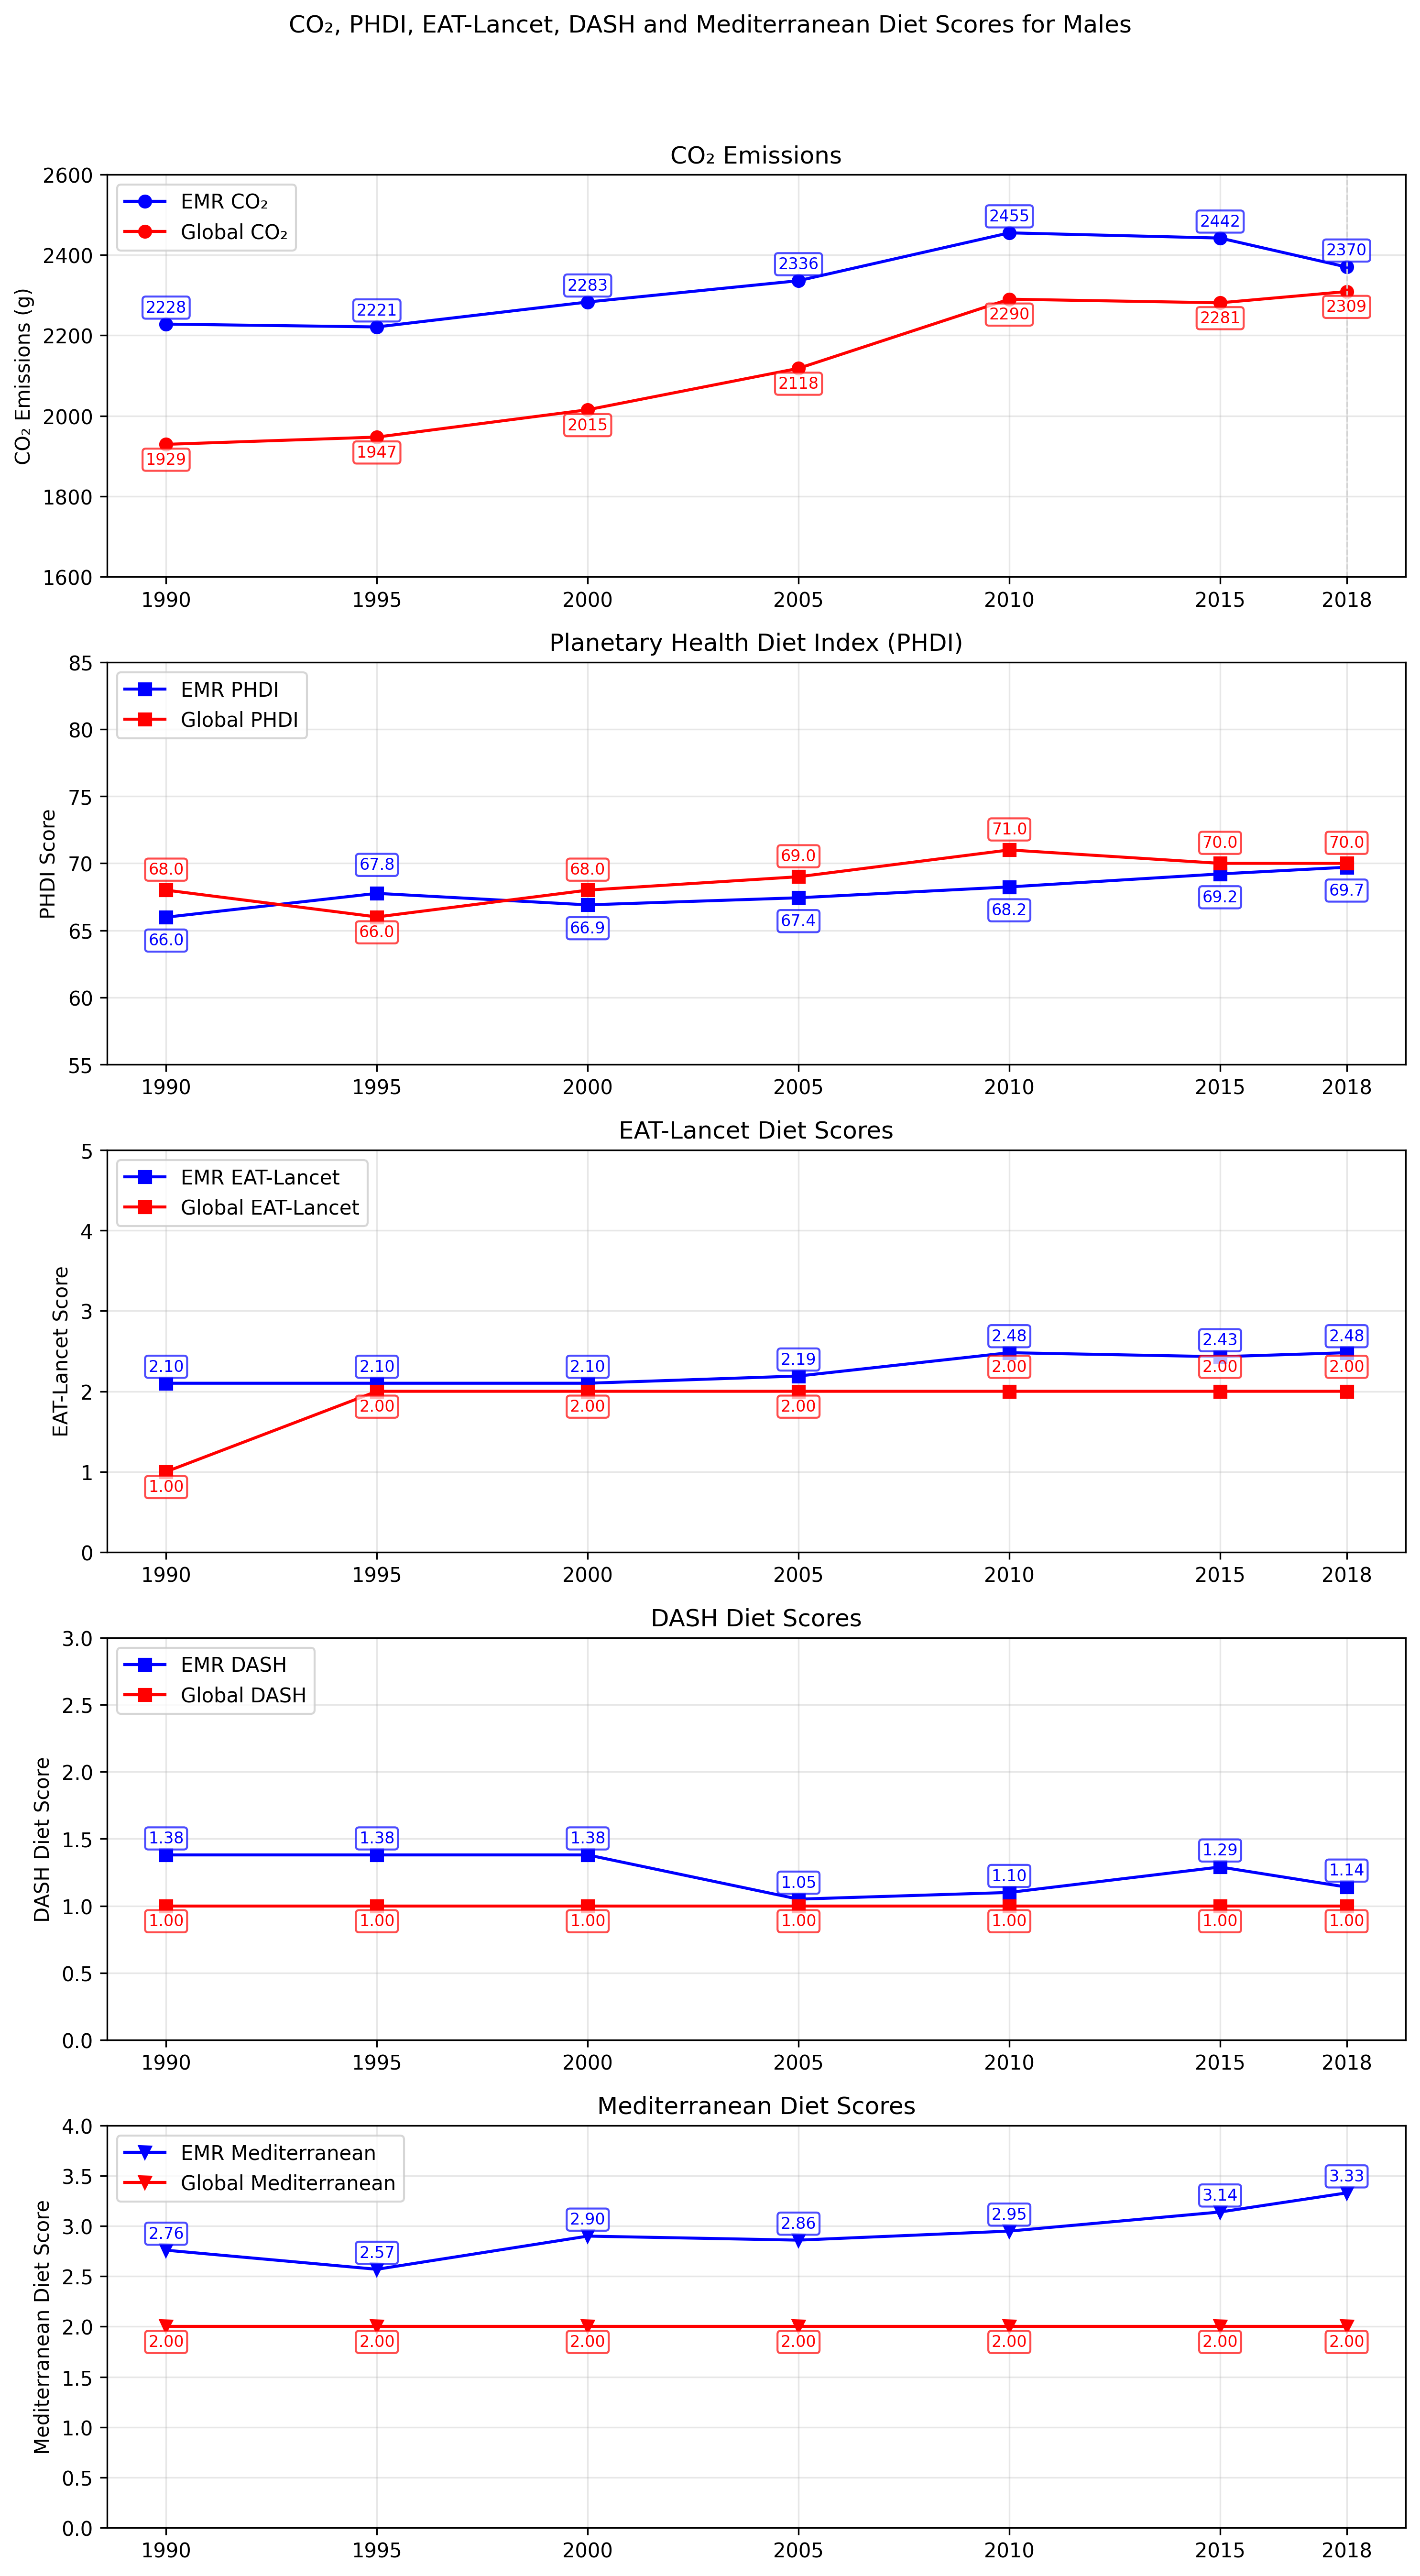

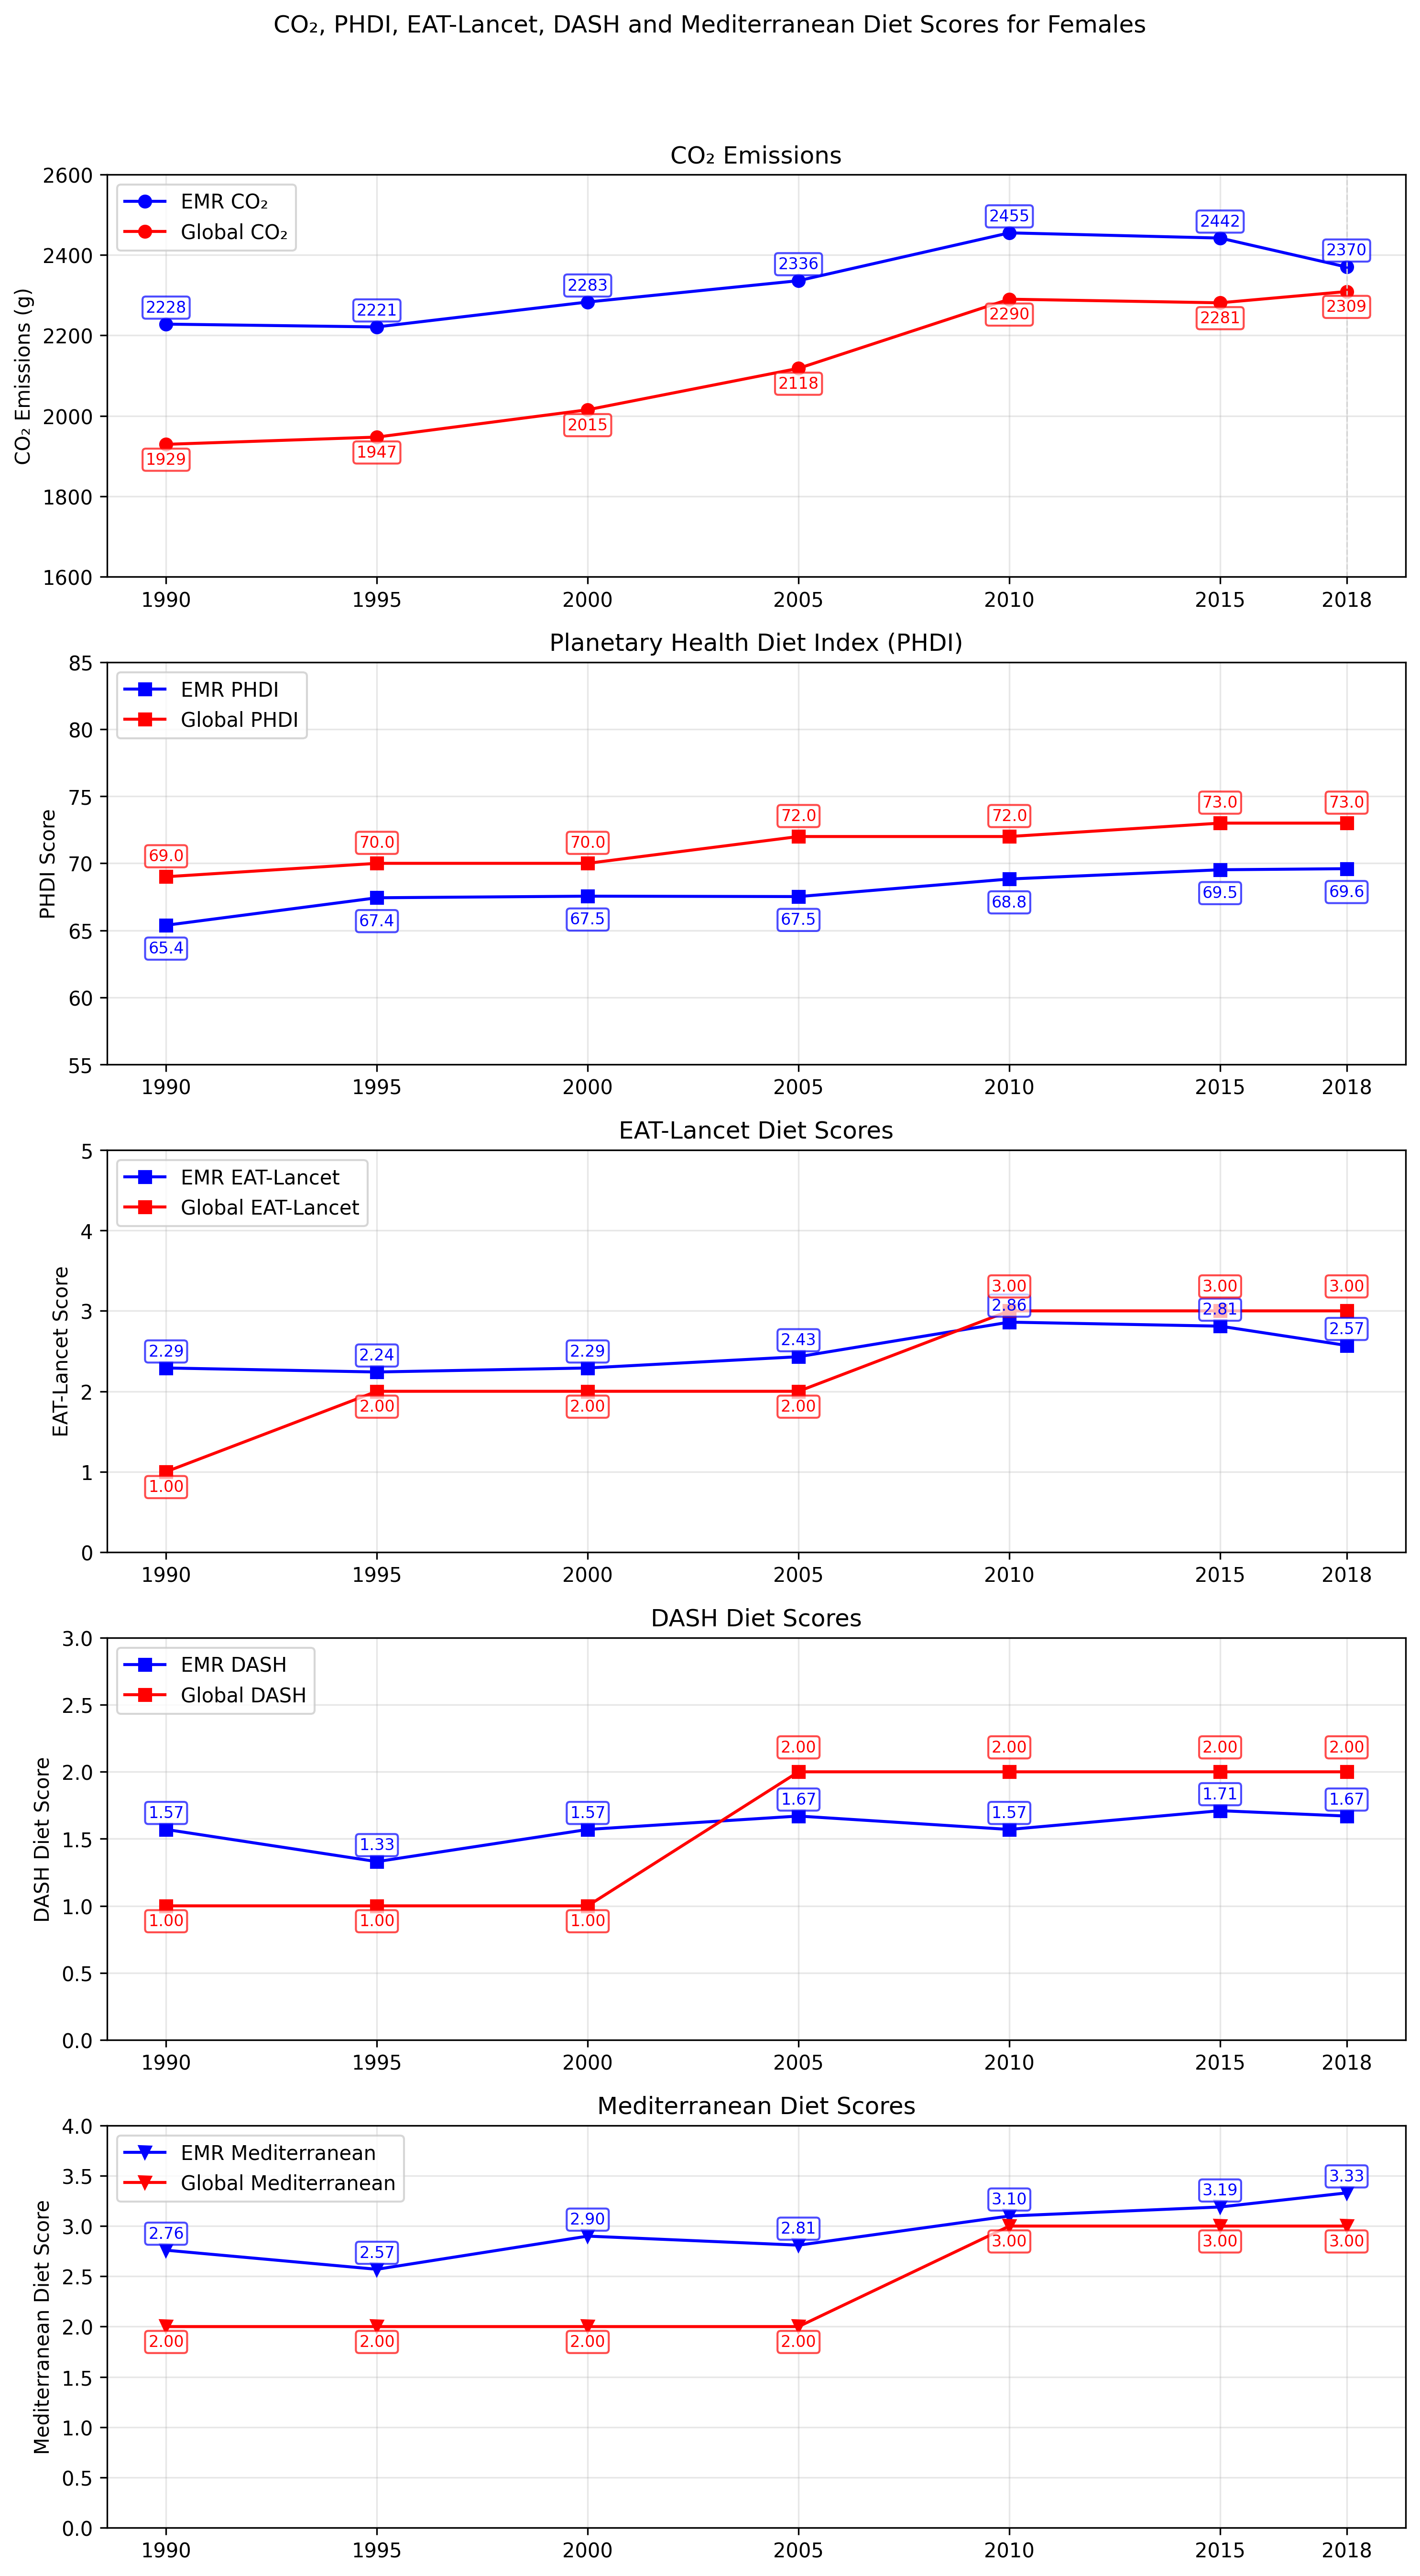

In [10]:
# ---------- Plot for males ----------
plot_five_panel(
    emr_co2, global_co2,
    em_dash_male, gl_dash_male,
    em_eat_male, gl_eat_male,
    emr_medit_males, glo_medit_males,
    em_phdi_male, gl_phdi_male,
    gender="males"
)

# ---------- Plot for females ----------
plot_five_panel(
    emr_co2, global_co2,
    em_dash_female, gl_dash_female,
    em_eat_female, gl_eat_female,
    emr_medit_females, glo_medit_females,
    em_phdi_female, gl_phdi_female,
    gender="females"
)